In [32]:
import pandas as pd

#fix skewness
import numpy as np
from sklearn.preprocessing import PowerTransformer
from matplotlib import pyplot as plt

df = pd.read_csv('cleaned_data_extra_amputations.csv')

# Square root
sqrt_vars = ['bmi', 'hdl']
for col in sqrt_vars:
    df[col + '_sqrt'] = np.sqrt(df[col])

# Log (use log1p to handle any zeros safely)
log_vars = ['diabp', 'hba1c', 'ldl', 'tri', 'serumcre']
for col in log_vars:
    df[col + '_log'] = np.log1p(df[col])

# smokingyears → binary
df['is_smoker'] = (df['smokingyears'] > 0).astype(int)

# Optional: Yeo-Johnson for everything (handles negatives & zeros)
pt = PowerTransformer(method='yeo-johnson')
df[log_vars] = pt.fit_transform(df[log_vars])

Class distribution:
target
0    171
1    109
Name: count, dtype: int64

Feature matrix shape: (280, 15)
Missing values per feature:
 Series([], dtype: int64)

scale_pos_weight = 1.57  (neg=137, pos=87)

Best AUC: 0.612534149462254
Best params: {'subsample': 0.8, 'reg_alpha': 0, 'n_estimators': 150, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.6}
5-fold CV ROC-AUC: 0.601 ± 0.025

Test set results:
                 precision    recall  f1-score   support

No complication       0.61      0.68      0.64        34
   Complication       0.39      0.32      0.35        22

       accuracy                           0.54        56
      macro avg       0.50      0.50      0.49        56
   weighted avg       0.52      0.54      0.53        56

ROC-AUC: 0.557


Top features by gain importance:
smokingyears                0.195167
hba1c                       0.100813
serumcre                    0.094665
tri                         0.088177
race               

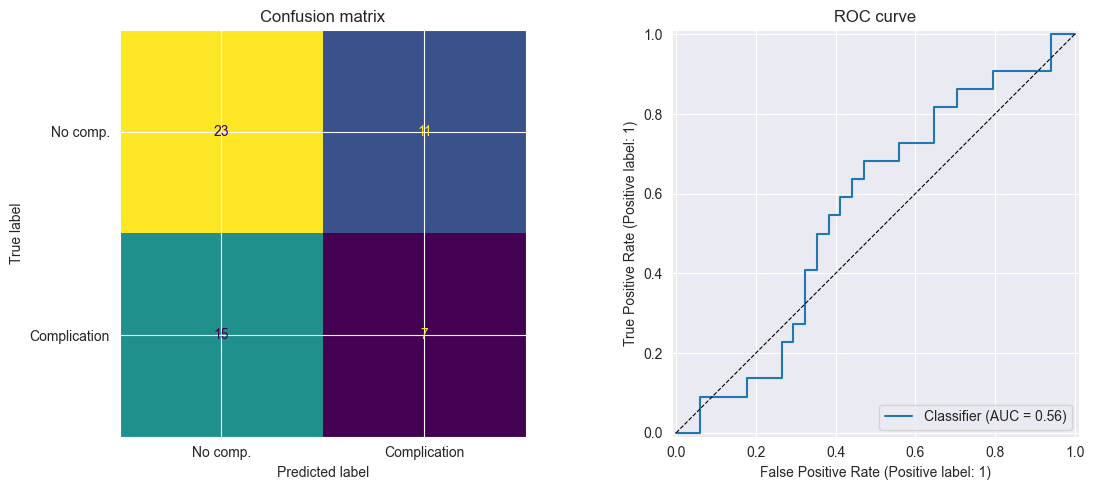

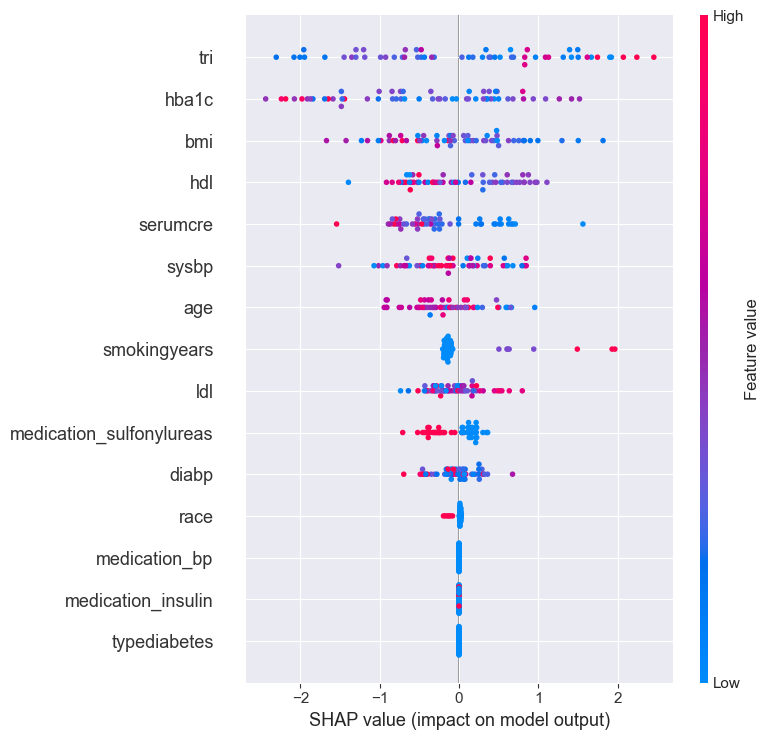

In [33]:
"""
XGBoost pipeline: predicting diabetic macrovascular complications
Dataset columns used:
  Features : gender, age, race, bmi, marital_status, typediabetes,
             smokingyears, sysbp, diabp, hba1c, hdl, ldl, tri,
             serumcre, medication_insulin, medication_sulfonylureas,
             medication_bp
  Target   : diabetic_macrovascular_complications  ->  binary 0/1
"""

import pandas as pd
import numpy as np
from io import StringIO

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)
import xgboost as xgb
import matplotlib.pyplot as plt
import shap
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import RandomizedSearchCV

df = pd.read_csv("cleaned_data.csv")

df["target"] = (
    df["diabetic_macrovascular_complications"]
    .astype(str)
    .str.strip()
    .apply(lambda x: 0 if x in ("0", "nan", "") else 1)
)

print("Class distribution:")
print(df["target"].value_counts())
print()


categorical = ["race", "typediabetes",
               "medication_insulin", "medication_sulfonylureas", "medication_bp"]
numerical   = ["age", "bmi", "smokingyears", "sysbp", "diabp",
               "hba1c", "hdl", "ldl", "tri", "serumcre"]

features = categorical + numerical

sm = SMOTE(random_state=42, k_neighbors=3)  

X = df[features]
y = df["target"]

X = X.apply(pd.to_numeric, errors="coerce")

print("Feature matrix shape:", X.shape)
print("Missing values per feature:\n", X.isnull().sum()[X.isnull().sum() > 0])
print()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

# ── 6. Compute scale_pos_weight for class imbalance ───────────────────────────
# scale_pos_weight = count(negative class) / count(positive class)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos if pos > 0 else 1.0
print(f"scale_pos_weight = {spw:.2f}  (neg={neg}, pos={pos})")
print()

model = xgb.XGBClassifier()

param_dist = {
    "max_depth":        [2, 3, 4],
    "n_estimators":     [50, 100, 150],
    "learning_rate":    [0.01, 0.05, 0.1],
    "min_child_weight": [3, 5, 10],
    "subsample":        [0.6, 0.7, 0.8],
    "colsample_bytree": [0.5, 0.6, 0.8],
    "reg_alpha":        [0, 0.1, 0.5],
}

search = RandomizedSearchCV(
    model, param_dist,
    n_iter=50,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)
search.fit(X_train, y_train)
print("Best AUC:", search.best_score_)
print("Best params:", search.best_params_)

"""lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", C=0.1, max_iter=1000))
])

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=3,          # keep shallow
    class_weight="balanced",
    random_state=42
)"""

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
print(f"5-fold CV ROC-AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print()

model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Test set results:")
print(classification_report(y_test, y_pred, target_names=["No complication", "Complication"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No comp.", "Complication"]).plot(
    ax=axes[0], colorbar=False
)
axes[0].set_title("Confusion matrix")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title("ROC curve")
axes[1].plot([0, 1], [0, 1], "k--", lw=0.8)

plt.tight_layout()
plt.plot()


explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test, feature_names=features, show=False)
plt.tight_layout()

plt.plot()

importance = pd.Series(
    model.feature_importances_, index=features
).sort_values(ascending=False)

print("\nTop features by gain importance:")
print(importance.to_string())